# 05 — Feature Engineering

**Nhiệm vụ:** tạo feature snapshot-aware cho từng purchase-event, kiểm soát future leakage, chia `train / embargo / test`, đánh giá chất lượng feature và lưu dataset đầu vào cho bước tiền xử lý/SMOTENC.

Notebook này hợp nhất phần Feature Engineering đang nằm trong file Churn Labeling với các nội dung hợp lệ còn thiếu trong `05_Feature.ipynb` cũ.


## Cell 01 — Khởi tạo môi trường, Drive và đường dẫn


In [5]:
%pip -q install pyspark pandas numpy scikit-learn hvplot holoviews panel jupyter_bokeh

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from pathlib import Path
import numpy as np
import pandas as pd
import hvplot.pandas
import holoviews as hv
import panel as pn

from pyspark.sql import SparkSession, functions as F

hv.extension("bokeh")
pn.extension()

spark = (
    SparkSession.builder
    .appName("OlistFeatureEngineering")
    .getOrCreate()
)

data_dir = Path(
    "/content/drive/MyDrive/BigData/DA-BigData/code/data"
)

processed_dir = data_dir / "processed"
processed_dir.mkdir(
    parents=True,
    exist_ok=True
)

snapshot_labeled_dir = (
    processed_dir
    / "olist_customer_purchase_event_snapshots_labeled_180"
)

feature_output_dir = (
    processed_dir
    / "olist_customer_churn_features_temporal"
)

selected_output_dir = (
    processed_dir
    / "olist_customer_churn_features_selected"
)

extended_output_dir = (
    processed_dir
    / "olist_customer_churn_features_candidates_extended"
)

orders_prepared_path = (
    processed_dir
    / "olist_orders_prepared.csv"
)

orders_raw_path = (
    data_dir
    / "olist_orders_dataset.csv"
)

customers_path = (
    data_dir
    / "olist_customers_dataset.csv"
)

items_path = (
    data_dir
    / "olist_order_items_dataset.csv"
)

payments_path = (
    data_dir
    / "olist_order_payments_dataset.csv"
)

reviews_path = (
    processed_dir
    / "olist_review_order_links_audit.csv"
)

products_prepared_path = (
    processed_dir
    / "olist_products_prepared.csv"
)

payment_audit_path = (
    processed_dir
    / "olist_order_payments_prepared.csv"
)

required_paths = [
    snapshot_labeled_dir,
    customers_path,
    items_path,
    payments_path,
    reviews_path,
    products_prepared_path,
    payment_audit_path
]

if (
    not orders_prepared_path.exists()
    and not orders_raw_path.exists()
):
    raise FileNotFoundError(
        "Không tìm thấy orders prepared/raw"
    )

missing_paths = [
    str(p)
    for p in required_paths
    if not p.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Thiếu dữ liệu đầu vào:\n"
        + "\n".join(missing_paths)
    )

orders_path = (
    orders_prepared_path
    if orders_prepared_path.exists()
    else orders_raw_path
)

def read_csv(
    path,
    multiline=False
):
    reader = (
        spark.read
        .option("header", True)
        .option("inferSchema", True)
    )

    if multiline:
        reader = (
            reader
            .option("multiLine", True)
        )

    return reader.csv(
        str(path)
    )

print("=" * 70)
print("FEATURE ENGINEERING INPUT")
print("=" * 70)

print(
    "Data directory       :",
    data_dir
)

print(
    "Labeled snapshots    :",
    snapshot_labeled_dir
)

print(
    "Orders source        :",
    orders_path
)

print(
    "Reviews source       :",
    reviews_path
)

print(
    "Products source      :",
    products_prepared_path
)

print(
    "Payment audit source :",
    payment_audit_path
)

print(
    "Temporal feature out :",
    feature_output_dir
)

print(
    "Selected feature out :",
    selected_output_dir
)

print(
    "Extended feature out :",
    extended_output_dir
)

print("\n✓ Feature Engineering sẽ dùng review đã xử lý")
print("✓ Không đọc lại olist_order_reviews_dataset.csv raw")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FEATURE ENGINEERING INPUT
Data directory       : /content/drive/MyDrive/BigData/DA-BigData/code/data
Labeled snapshots    : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_customer_purchase_event_snapshots_labeled_180
Orders source        : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_orders_prepared.csv
Reviews source       : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_review_order_links_audit.csv
Products source      : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_products_prepared.csv
Payment audit source : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_order_payments_prepared.csv
Temporal feature out : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_customer_churn_features_temporal
Selected feature out : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_customer_churn_features_selected
Extended feature out : /content/drive/MyDrive/BigDa

## Cell 02 — Đọc purchase-event snapshot đã có nhãn từ Churn Labeling


In [6]:
TRAIN_END = "2017-08-01"
TEST_START = "2018-02-01"

snapshots = (
    read_csv(snapshot_labeled_dir)
    .withColumn("snapshot_at", F.to_timestamp("snapshot_at"))
    .withColumn("snapshot_date", F.to_date("snapshot_date"))
    .withColumn("previous_purchase_at", F.to_timestamp("previous_purchase_at"))
    .withColumn("next_purchase_at", F.to_timestamp("next_purchase_at"))
    .withColumn("followup_end_180", F.to_timestamp("followup_end_180"))
    .withColumn("purchase_sequence", F.col("purchase_sequence").cast("int"))
    .withColumn("days_since_previous_purchase", F.col("days_since_previous_purchase").cast("double"))
    .withColumn("customer_tenure_days", F.col("customer_tenure_days").cast("double"))
    .withColumn("avg_interpurchase_days_to_snapshot", F.col("avg_interpurchase_days_to_snapshot").cast("double"))
    .withColumn("max_interpurchase_days_to_snapshot", F.col("max_interpurchase_days_to_snapshot").cast("double"))
    .withColumn("churn_180", F.col("churn_180").cast("int"))
    .select(
        "customer_unique_id",
        "snapshot_order_id",
        "purchase_sequence",
        "snapshot_at",
        "snapshot_date",
        "previous_purchase_at",
        "days_since_previous_purchase",
        "customer_tenure_days",
        "avg_interpurchase_days_to_snapshot",
        "max_interpurchase_days_to_snapshot",
        "followup_end_180",
        "churn_180"
    )
    .cache()
)

print("Số labeled purchase-event snapshot:", snapshots.count())
print("Số khách:", snapshots.select("customer_unique_id").distinct().count())


Số labeled purchase-event snapshot: 58372
Số khách: 56487


## Cell 03 — Chuẩn bị order/item/payment/product facts

Ưu tiên bảng đã prepared ở bước 02 khi có. Dữ liệu line-level `order_items`, `payments`, `reviews` vẫn được đọc để tạo các feature chi tiết mà bảng aggregate chưa lưu.


In [7]:
orders = read_csv(orders_path)
customers = read_csv(customers_path).select("customer_id", "customer_unique_id")
items = read_csv(items_path)
payments = read_csv(payments_path)
reviews = read_csv(reviews_path, multiline=True)

products = read_csv(products_prepared_path) if products_prepared_path.exists() else None
payment_audit = read_csv(payment_audit_path) if payment_audit_path.exists() else None

item_source = items
if products is not None:
    item_source = item_source.join(
        products.select("product_id", "product_category_name", "product_weight_g"),
        "product_id",
        "left"
    )
else:
    item_source = (
        item_source
        .withColumn("product_category_name", F.lit(None).cast("string"))
        .withColumn("product_weight_g", F.lit(None).cast("double"))
    )

item_source = (
    item_source
    .withColumn("price_num", F.col("price").cast("double"))
    .withColumn("freight_num", F.col("freight_value").cast("double"))
    .withColumn("weight_num", F.col("product_weight_g").cast("double"))
    .withColumn(
        "missing_category_flag",
        F.when(
            F.col("product_category_name").isNull()
            | (F.trim(F.col("product_category_name")) == ""),
            1
        ).otherwise(0)
    )
)

item_facts = (
    item_source
    .groupBy("order_id")
    .agg(
        F.count("*").alias("item_count"),
        F.countDistinct("product_id").alias("distinct_products_in_order"),
        F.countDistinct("seller_id").alias("distinct_sellers_in_order"),
        F.countDistinct("product_category_name").alias("categories_in_order"),
        F.sum("price_num").alias("order_item_value"),
        F.sum("freight_num").alias("order_freight"),
        F.avg(F.when(F.col("weight_num") > 0, F.col("weight_num"))).alias("mean_product_weight_g"),
        F.sum("missing_category_flag").alias("items_missing_category_in_order")
    )
)

payment_source = (
    payments
    .withColumn("payment_num", F.col("payment_value").cast("double"))
    .withColumn("installments_num", F.col("payment_installments").cast("int"))
)

payment_facts = (
    payment_source
    .groupBy("order_id")
    .agg(
        F.sum("payment_num").alias("order_payment"),
        F.count("*").alias("payment_lines"),
        F.countDistinct("payment_type").alias("payment_types_in_order"),
        F.max("installments_num").alias("max_installments_in_order"),
        F.avg(F.when(F.col("installments_num") > 0, F.col("installments_num"))).alias("avg_installments_in_order"),
        F.max(F.when(F.col("payment_type") == "credit_card", 1).otherwise(0)).alias("used_credit_card"),
        F.max(
            F.when(
                F.col("installments_num").isNull() | (F.col("installments_num") <= 0),
                1
            ).otherwise(0)
        ).alias("invalid_installments")
    )
)

order_facts = (
    orders
    .filter(F.col("order_status") == "delivered")
    .join(customers, "customer_id", "inner")
    .select(
        "order_id",
        "customer_unique_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    )
    .join(item_facts, "order_id", "left")
    .join(payment_facts, "order_id", "left")
    .withColumn("purchase_at", F.to_timestamp("order_purchase_timestamp"))
    .withColumn("delivered_at", F.to_timestamp("order_delivered_customer_date"))
    .withColumn("estimated_delivery_at", F.to_timestamp("order_estimated_delivery_date"))
)

if payment_audit is not None:
    order_facts = order_facts.join(
        payment_audit.select("order_id", "reconciliation_status"),
        "order_id",
        "left"
    )
else:
    order_facts = order_facts.withColumn("reconciliation_status", F.lit(None).cast("string"))

order_facts = (
    order_facts
    .withColumn(
        "delivery_days",
        F.when(
            F.col("delivered_at").isNotNull()
            & (F.col("delivered_at") >= F.col("purchase_at")),
            (F.unix_timestamp("delivered_at") - F.unix_timestamp("purchase_at")) / 86400.0
        )
    )
    .withColumn(
        "late_flag",
        F.when(
            F.col("delivered_at").isNotNull()
            & F.col("estimated_delivery_at").isNotNull(),
            F.when(F.col("delivered_at") > F.col("estimated_delivery_at"), 1).otherwise(0)
        )
    )
    .withColumn(
        "payment_for_model",
        F.when(
            F.col("reconciliation_status").isNull()
            | (F.col("reconciliation_status") == "KHOP"),
            F.col("order_payment")
        )
    )
    .cache()
)

print("Delivered order facts:", order_facts.count())


Delivered order facts: 96478


## Cell 04 — Tạo feature tại snapshot và temporal split

Quy tắc leakage: product/payment của đơn hiện tại được phép dùng vì đã biết tại thời điểm mua; delivery/review chỉ được dùng khi timestamp sự kiện `<= snapshot_at`. Khóa observation là `customer_unique_id + snapshot_order_id`.


In [8]:
history = (
    snapshots.alias("s")
    .join(
        order_facts.alias("o"),
        (
            F.col("s.customer_unique_id") == F.col("o.customer_unique_id")
        )
        & (
            (F.col("o.purchase_at") < F.col("s.snapshot_at"))
            | (
                (F.col("o.purchase_at") == F.col("s.snapshot_at"))
                & (F.col("o.order_id") <= F.col("s.snapshot_order_id"))
            )
        ),
        "inner"
    )
    .select(
        F.col("s.customer_unique_id").alias("customer_unique_id"),
        F.col("s.snapshot_order_id").alias("snapshot_order_id"),
        F.col("s.snapshot_at").alias("snapshot_at"),
        F.col("s.snapshot_date").alias("snapshot_date"),
        F.col("o.order_id").alias("history_order_id"),
        F.col("o.purchase_at").alias("purchase_at"),
        F.col("o.delivered_at").alias("delivered_at"),
        F.col("o.delivery_days").alias("delivery_days"),
        F.col("o.late_flag").alias("late_flag"),
        F.col("o.payment_for_model").alias("payment_for_model"),
        F.col("o.order_item_value").alias("order_item_value"),
        F.col("o.order_freight").alias("order_freight"),
        F.col("o.item_count").alias("item_count"),
        F.col("o.distinct_products_in_order").alias("distinct_products_in_order"),
        F.col("o.distinct_sellers_in_order").alias("distinct_sellers_in_order"),
        F.col("o.categories_in_order").alias("categories_in_order"),
        F.col("o.items_missing_category_in_order").alias("items_missing_category_in_order"),
        F.col("o.mean_product_weight_g").alias("mean_product_weight_g"),
        F.col("o.payment_lines").alias("payment_lines"),
        F.col("o.max_installments_in_order").alias("max_installments_in_order"),
        F.col("o.avg_installments_in_order").alias("avg_installments_in_order"),
        F.col("o.used_credit_card").alias("used_credit_card"),
        F.col("o.invalid_installments").alias("invalid_installments"),
        F.col("o.reconciliation_status").alias("reconciliation_status")
    )
    .withColumn(
        "delivery_known",
        F.col("delivered_at").isNotNull() & (F.col("delivered_at") <= F.col("snapshot_at"))
    )
    .cache()
)

transaction_features = (
    history
    .groupBy("customer_unique_id", "snapshot_order_id", "snapshot_at", "snapshot_date")
    .agg(
        F.countDistinct("history_order_id").alias("frequency_orders"),
        F.sum(F.when(F.col("purchase_at") >= F.expr("snapshot_at - INTERVAL 30 DAYS"), 1).otherwise(0)).alias("orders_last_30d"),
        F.sum(F.when(F.col("purchase_at") >= F.expr("snapshot_at - INTERVAL 90 DAYS"), 1).otherwise(0)).alias("orders_last_90d"),
        F.sum(F.when(F.col("purchase_at") >= F.expr("snapshot_at - INTERVAL 180 DAYS"), 1).otherwise(0)).alias("orders_last_180d"),
        F.sum("payment_for_model").alias("monetary_total"),
        F.avg("payment_for_model").alias("mean_order_value"),
        F.sum("order_freight").alias("freight_total"),
        F.avg("order_freight").alias("avg_freight"),
        F.sum("order_item_value").alias("total_product_price"),
        F.sum(F.coalesce(F.col("item_count"), F.lit(0))).alias("total_items"),
        F.sum(F.coalesce(F.col("distinct_products_in_order"), F.lit(0))).alias("sum_distinct_products_per_order"),
        F.sum(F.coalesce(F.col("distinct_sellers_in_order"), F.lit(0))).alias("sum_distinct_sellers_per_order"),
        F.sum(F.coalesce(F.col("categories_in_order"), F.lit(0))).alias("sum_categories_per_order"),
        F.sum(F.coalesce(F.col("items_missing_category_in_order"), F.lit(0))).alias("items_missing_category"),
        F.avg("mean_product_weight_g").alias("mean_order_product_weight_g"),
        F.count(F.when(F.col("delivery_known"), F.lit(1))).alias("delivered_orders_known"),
        F.avg(F.when(F.col("delivery_known"), F.col("delivery_days"))).alias("mean_delivery_days_known"),
        F.sum(F.when(F.col("delivery_known") & (F.col("late_flag") == 1), 1).otherwise(0)).alias("late_orders_known"),
        F.max(F.when(F.col("delivery_known"), F.col("delivered_at"))).alias("max_delivery_event_at"),
        F.sum(F.coalesce(F.col("payment_lines"), F.lit(0))).alias("total_payment_lines"),
        F.max("max_installments_in_order").alias("max_installments"),
        F.avg("avg_installments_in_order").alias("avg_installments_order_mean"),
        F.sum(F.coalesce(F.col("used_credit_card"), F.lit(0))).alias("credit_card_orders"),
        F.sum(F.coalesce(F.col("invalid_installments"), F.lit(0))).alias("orders_invalid_installments"),
        F.sum(
            F.when(
                F.col("reconciliation_status").isNotNull()
                & (F.col("reconciliation_status") != "KHOP"),
                1
            ).otherwise(0)
        ).alias("orders_payment_not_matched")
    )
    .withColumn(
        "late_delivery_ratio",
        F.when(
            F.col("delivered_orders_known") > 0,
            F.col("late_orders_known") / F.col("delivered_orders_known")
        )
    )
)

current_order_features = (
    snapshots.alias("s")
    .join(order_facts.alias("o"), F.col("s.snapshot_order_id") == F.col("o.order_id"), "left")
    .select(
        F.col("s.customer_unique_id").alias("customer_unique_id"),
        F.col("s.snapshot_order_id").alias("snapshot_order_id"),
        F.col("o.item_count").alias("current_item_count"),
        F.col("o.distinct_products_in_order").alias("current_distinct_products"),
        F.col("o.distinct_sellers_in_order").alias("current_distinct_sellers"),
        F.col("o.categories_in_order").alias("current_categories"),
        F.col("o.payment_for_model").alias("current_order_payment"),
        F.col("o.order_freight").alias("current_order_freight"),
        F.col("o.max_installments_in_order").alias("current_max_installments"),
        F.col("o.used_credit_card").alias("current_used_credit_card")
    )
)

order_map = order_facts.select("order_id", "customer_unique_id", "purchase_at")

item_event_base = item_source.join(order_map, "order_id", "inner")
item_history = (
    snapshots.alias("s")
    .join(
        item_event_base.alias("i"),
        (F.col("s.customer_unique_id") == F.col("i.customer_unique_id"))
        & (
            (F.col("i.purchase_at") < F.col("s.snapshot_at"))
            | (
                (F.col("i.purchase_at") == F.col("s.snapshot_at"))
                & (F.col("i.order_id") <= F.col("s.snapshot_order_id"))
            )
        ),
        "inner"
    )
)

product_detail_features = (
    item_history
    .select(
        F.col("s.customer_unique_id").alias("customer_unique_id"),
        F.col("s.snapshot_order_id").alias("snapshot_order_id"),
        F.col("i.product_id").alias("product_id"),
        F.col("i.product_category_name").alias("product_category_name"),
        F.col("i.price_num").alias("price_num"),
        F.col("i.purchase_at").alias("purchase_at")
    )
    .groupBy("customer_unique_id", "snapshot_order_id")
    .agg(
        F.countDistinct("product_id").alias("unique_products"),
        F.countDistinct("product_category_name").alias("unique_categories"),
        F.avg("price_num").alias("avg_product_price"),
        F.max("purchase_at").alias("max_item_purchase_at")
    )
)

payment_event_base = payment_source.join(order_map, "order_id", "inner")
payment_history = (
    snapshots.alias("s")
    .join(
        payment_event_base.alias("p"),
        (F.col("s.customer_unique_id") == F.col("p.customer_unique_id"))
        & (
            (F.col("p.purchase_at") < F.col("s.snapshot_at"))
            | (
                (F.col("p.purchase_at") == F.col("s.snapshot_at"))
                & (F.col("p.order_id") <= F.col("s.snapshot_order_id"))
            )
        ),
        "inner"
    )
)

payment_detail_features = (
    payment_history
    .select(
        F.col("s.customer_unique_id").alias("customer_unique_id"),
        F.col("s.snapshot_order_id").alias("snapshot_order_id"),
        F.col("p.installments_num").alias("installments_num"),
        F.col("p.payment_type").alias("payment_type"),
        F.col("p.purchase_at").alias("purchase_at")
    )
    .groupBy("customer_unique_id", "snapshot_order_id")
    .agg(
        F.avg(F.when(F.col("installments_num") > 0, F.col("installments_num"))).alias("avg_installments"),
        F.countDistinct("payment_type").alias("payment_type_count"),
        F.max("purchase_at").alias("max_payment_purchase_at")
    )
)

unique_reviews = (
    reviews
    .filter(F.col("review_id").isNotNull())
    .withColumn("answer_at", F.to_timestamp("review_answer_timestamp"))
    .withColumn("score_num", F.col("review_score").cast("int"))
    .groupBy("review_id")
    .agg(
        F.countDistinct("order_id").alias("linked_orders"),
        F.min("order_id").alias("order_id"),
        F.countDistinct("score_num").alias("distinct_scores"),
        F.min("score_num").alias("review_score"),
        F.min("answer_at").alias("answer_at_min"),
        F.max("answer_at").alias("answer_at_max")
    )
    .filter(
        (F.col("linked_orders") == 1)
        & (F.col("distinct_scores") == 1)
        & F.col("review_score").between(1, 5)
        & F.col("answer_at_min").isNotNull()
        & (F.col("answer_at_min") == F.col("answer_at_max"))
    )
    .select("review_id", "order_id", "review_score", F.col("answer_at_min").alias("answer_at"))
)

review_features = (
    history
    .select(
        "customer_unique_id",
        "snapshot_order_id",
        "snapshot_at",
        F.col("history_order_id").alias("order_id")
    )
    .join(unique_reviews, "order_id", "inner")
    .filter(F.col("answer_at") <= F.col("snapshot_at"))
    .groupBy("customer_unique_id", "snapshot_order_id")
    .agg(
        F.countDistinct("review_id").alias("known_review_count"),
        F.avg("review_score").alias("mean_known_review_score"),
        F.sum(F.when(F.col("review_score") <= 2, 1).otherwise(0)).alias("low_score_review_count"),
        F.max("answer_at").alias("max_review_answer_at")
    )
    .withColumn(
        "negative_review_ratio",
        F.when(
            F.col("known_review_count") > 0,
            F.col("low_score_review_count") / F.col("known_review_count")
        )
    )
)

features = (
    snapshots
    .join(transaction_features, ["customer_unique_id", "snapshot_order_id", "snapshot_at", "snapshot_date"], "left")
    .join(current_order_features, ["customer_unique_id", "snapshot_order_id"], "left")
    .join(product_detail_features, ["customer_unique_id", "snapshot_order_id"], "left")
    .join(payment_detail_features, ["customer_unique_id", "snapshot_order_id"], "left")
    .join(review_features, ["customer_unique_id", "snapshot_order_id"], "left")
    .withColumn("prior_orders_count", F.col("purchase_sequence") - 1)
    .withColumn("known_review_count", F.coalesce(F.col("known_review_count"), F.lit(0)))
    .withColumn("low_score_review_count", F.coalesce(F.col("low_score_review_count"), F.lit(0)))
    .withColumn("negative_review_ratio", F.coalesce(F.col("negative_review_ratio"), F.lit(0.0)))
    .withColumn(
        "temporal_split",
        F.when(F.col("snapshot_date") <= F.to_date(F.lit(TRAIN_END)), "train")
        .when(F.col("snapshot_date") >= F.to_date(F.lit(TEST_START)), "test")
        .otherwise("embargo")
    )
    .cache()
)

print("Feature rows:", features.count())


Feature rows: 58372


## Cell 05 — Kiểm tra future leakage, khóa observation và lưu temporal feature dataset


In [9]:
duplicate_feature_keys = (
    features
    .groupBy("customer_unique_id", "snapshot_order_id")
    .count()
    .filter(F.col("count") > 1)
    .count()
)

frequency_mismatch = features.filter(F.col("frequency_orders") != F.col("purchase_sequence")).count()

train_label_end = (
    features
    .filter(F.col("temporal_split") == "train")
    .agg(F.max("followup_end_180").alias("train_label_end"))
    .first()["train_label_end"]
)

test_start_at = (
    features
    .filter(F.col("temporal_split") == "test")
    .agg(F.min("snapshot_at").alias("test_start_at"))
    .first()["test_start_at"]
)

if train_label_end is None or test_start_at is None:
    raise ValueError("Train hoặc test rỗng sau temporal split")

if train_label_end >= test_start_at:
    raise ValueError(
        f"Leakage thời gian: nhãn train kết thúc {train_label_end}, test bắt đầu {test_start_at}"
    )

leakage_checks = {
    "delivery": "max_delivery_event_at",
    "review": "max_review_answer_at",
    "item": "max_item_purchase_at",
    "payment": "max_payment_purchase_at",
}

leakage_results = {}
for name, ts_col in leakage_checks.items():
    n = (
        features
        .filter(F.col(ts_col).isNotNull() & (F.col(ts_col) > F.col("snapshot_at")))
        .count()
    )
    leakage_results[name] = n

print("Duplicate customer + snapshot_order:", duplicate_feature_keys)
print("frequency_orders != purchase_sequence:", frequency_mismatch)
print("Train label end                    :", train_label_end)
print("Test start                         :", test_start_at)
print("Future leakage checks              :", leakage_results)

if duplicate_feature_keys > 0 or frequency_mismatch > 0 or any(v > 0 for v in leakage_results.values()):
    raise ValueError("Kiểm tra feature chưa đạt")

audit_ts_cols = list(leakage_checks.values())
features_to_save = features.drop(*audit_ts_cols)

(
    features_to_save
    .repartition(8, "snapshot_date")
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(feature_output_dir))
)

print("Đã lưu temporal feature dataset:", feature_output_dir)

features_to_save.groupBy("temporal_split").agg(
    F.count("*").alias("so_event"),
    F.countDistinct("customer_unique_id").alias("so_khach"),
    F.sum(F.when(F.col("churn_180") == 1, 1).otherwise(0)).alias("so_churn"),
    F.sum(F.when(F.col("churn_180") == 0, 1).otherwise(0)).alias("so_non_churn"),
    F.round(100 * F.avg("churn_180"), 2).alias("ty_le_churn_pct")
).orderBy("temporal_split").show(truncate=False)


Duplicate customer + snapshot_order: 0
frequency_orders != purchase_sequence: 0
Train label end                    : 2018-01-28 23:41:09
Test start                         : 2018-02-01 00:24:55
Future leakage checks              : {'delivery': 0, 'review': 0, 'item': 0, 'payment': 0}
Đã lưu temporal feature dataset: /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_customer_churn_features_temporal
+--------------+--------+--------+--------+------------+---------------+
|temporal_split|so_event|so_khach|so_churn|so_non_churn|ty_le_churn_pct|
+--------------+--------+--------+--------+------------+---------------+
|embargo       |32531   |31755   |31491   |1040        |96.8           |
|test          |7608    |7400    |6672    |936         |87.7           |
|train         |18233   |17763   |17604   |629         |96.55          |
+--------------+--------+--------+--------+------------+---------------+



## Cell 06


In [16]:
raw = read_csv(feature_output_dir)

TARGET_COLUMN = "churn_180"

NON_FEATURE_COLUMNS = [
    "customer_unique_id",
    "snapshot_order_id",
    "snapshot_at",
    "snapshot_date",
    "previous_purchase_at",
    "next_purchase_at",
    "followup_end_180",
    "temporal_split",
    "churn_180",
    "churn_90",
    "churn_120",
    "gap_days",
    "label_status",
    "eligible_180"
]

CANDIDATE_FEATURES = [
    c
    for c in raw.columns
    if c not in NON_FEATURE_COLUMNS
]

if TARGET_COLUMN not in raw.columns:
    raise ValueError(
        f"Không tìm thấy target {TARGET_COLUMN}"
    )

if "temporal_split" not in raw.columns:
    raise ValueError(
        "Không tìm thấy temporal_split"
    )

if not CANDIDATE_FEATURES:
    raise ValueError(
        "Không tìm thấy candidate feature"
    )

train_count = (
    raw
    .filter(
        F.col("temporal_split") == "train"
    )
    .count()
)

embargo_count = (
    raw
    .filter(
        F.col("temporal_split") == "embargo"
    )
    .count()
)

test_count = (
    raw
    .filter(
        F.col("temporal_split") == "test"
    )
    .count()
)

print("=" * 70)
print("FEATURE ENGINEERING — PIPELINE MỚI")
print("=" * 70)

print(
    "Tổng số cột:",
    len(raw.columns)
)

print(
    "Số candidate feature:",
    len(CANDIDATE_FEATURES)
)

print(
    "TRAIN events:",
    train_count
)

print(
    "EMBARGO events:",
    embargo_count
)

print(
    "TEST events:",
    test_count
)

print("\nCANDIDATE FEATURES")

for i, feature in enumerate(
    CANDIDATE_FEATURES,
    start=1
):
    print(
        f"{i:02d}. {feature}"
    )

print(
    "\n✓ Candidate feature được lấy trực tiếp "
    "từ dataset Feature Engineering hiện tại"
)

print(
    "✓ Không sử dụng danh sách feature "
    "từ notebook cũ"
)

print(
    "✓ Chưa loại feature nào tại Cell 06"
)

FEATURE ENGINEERING — PIPELINE MỚI
Tổng số cột: 56
Số candidate feature: 48
TRAIN events: 18233
EMBARGO events: 32531
TEST events: 7608

CANDIDATE FEATURES
01. purchase_sequence
02. days_since_previous_purchase
03. customer_tenure_days
04. avg_interpurchase_days_to_snapshot
05. max_interpurchase_days_to_snapshot
06. frequency_orders
07. orders_last_30d
08. orders_last_90d
09. orders_last_180d
10. monetary_total
11. mean_order_value
12. freight_total
13. avg_freight
14. total_product_price
15. total_items
16. sum_distinct_products_per_order
17. sum_distinct_sellers_per_order
18. sum_categories_per_order
19. items_missing_category
20. mean_order_product_weight_g
21. delivered_orders_known
22. mean_delivery_days_known
23. late_orders_known
24. total_payment_lines
25. max_installments
26. avg_installments_order_mean
27. credit_card_orders
28. orders_invalid_installments
29. orders_payment_not_matched
30. late_delivery_ratio
31. current_item_count
32. current_distinct_products
33. current_d

## Cell 07 — Thống kê missing, target signal và correlation trên TRAIN

Không dùng TEST để chọn feature. Đây là bước đánh giá các feature bổ sung trước khi quyết định thay đổi baseline.


In [17]:
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif

import numpy as np
import pandas as pd

HIGH_MISSING_THRESHOLD = 99.0
HIGH_CORRELATION_THRESHOLD = 0.95

train_numeric = (
    raw
    .filter(
        F.col("temporal_split") == "train"
    )
    .select(
        F.col(TARGET_COLUMN)
        .cast("int")
        .alias(TARGET_COLUMN),

        *[
            F.expr(
                f"try_cast(`{c}` as double)"
            ).alias(c)
            for c in CANDIDATE_FEATURES
        ]
    )
)

pdf = (
    train_numeric
    .toPandas()
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

pdf = pdf[
    pdf[TARGET_COLUMN].notna()
].copy()

pdf[TARGET_COLUMN] = (
    pd.to_numeric(
        pdf[TARGET_COLUMN],
        errors="coerce"
    )
)

pdf = pdf[
    pdf[TARGET_COLUMN].notna()
].copy()

pdf[TARGET_COLUMN] = (
    pdf[TARGET_COLUMN]
    .astype(int)
)

y = pdf[TARGET_COLUMN]

if y.nunique() < 2:
    raise ValueError(
        "TRAIN chỉ có một class target, "
        "không thể đánh giá feature."
    )

quality_rows = []

for feature in CANDIDATE_FEATURES:

    s = pd.to_numeric(
        pdf[feature],
        errors="coerce"
    )

    missing_count = int(
        s.isna().sum()
    )

    missing_pct = float(
        100 * s.isna().mean()
    )

    n_unique = int(
        s.nunique(
            dropna=True
        )
    )

    non_missing_count = int(
        s.notna().sum()
    )

    if non_missing_count > 0:

        minimum = float(
            s.min()
        )

        maximum = float(
            s.max()
        )

        median = float(
            s.median()
        )

    else:

        minimum = np.nan
        maximum = np.nan
        median = np.nan

    if n_unique <= 1:

        auc = 0.5
        mi = 0.0

    else:

        fill_value = (
            median
            if pd.notna(median)
            else 0.0
        )

        x = (
            s
            .fillna(fill_value)
            .astype(float)
        )

        try:

            auc_raw = roc_auc_score(
                y,
                x
            )

            auc = max(
                float(auc_raw),
                float(1 - auc_raw)
            )

        except Exception:

            auc = 0.5

        valid = s.dropna()

        is_integer_like = (
            len(valid) > 0
            and np.allclose(
                valid.values,
                np.round(
                    valid.values
                )
            )
        )

        discrete = bool(
            n_unique <= 30
            and is_integer_like
        )

        try:

            mi = float(
                mutual_info_classif(
                    x.to_numpy()
                    .reshape(-1, 1),

                    y.to_numpy(),

                    discrete_features=discrete,

                    random_state=42
                )[0]
            )

        except Exception:

            mi = 0.0

    quality_rows.append({
        "feature":
            feature,

        "missing_count":
            missing_count,

        "missing_pct":
            round(
                missing_pct,
                4
            ),

        "non_missing_count":
            non_missing_count,

        "n_unique":
            n_unique,

        "minimum":
            minimum,

        "median":
            median,

        "maximum":
            maximum,

        "univariate_auc":
            round(
                auc,
                6
            ),

        "mutual_information":
            round(
                mi,
                8
            )
    })

quality_df = pd.DataFrame(
    quality_rows
)

quality_df[
    "is_constant"
] = (
    quality_df[
        "n_unique"
    ] <= 1
)

quality_df[
    "high_missing"
] = (
    quality_df[
        "missing_pct"
    ]
    >= HIGH_MISSING_THRESHOLD
)

constant_features = (
    quality_df
    .loc[
        quality_df[
            "is_constant"
        ],
        "feature"
    ]
    .tolist()
)

high_missing_features = (
    quality_df
    .loc[
        quality_df[
            "high_missing"
        ],
        "feature"
    ]
    .tolist()
)

eligible_features = [
    feature
    for feature
    in CANDIDATE_FEATURES

    if (
        feature
        not in constant_features
        and feature
        not in high_missing_features
    )
]

if not eligible_features:
    raise ValueError(
        "Không còn feature sau kiểm tra "
        "constant và missing."
    )

corr_matrix = (
    pdf[
        eligible_features
    ]
    .corr(
        method="pearson"
    )
)

quality_lookup = (
    quality_df
    .set_index(
        "feature"
    )
)

priority_features = sorted(
    eligible_features,
    key=lambda feature: (
        -quality_lookup.loc[
            feature,
            "univariate_auc"
        ],
        -quality_lookup.loc[
            feature,
            "mutual_information"
        ],
        quality_lookup.loc[
            feature,
            "missing_pct"
        ],
        feature
    )
)

kept_features = []
correlated_drops = {}

for feature in priority_features:

    drop_feature = False

    for kept in kept_features:

        corr_value = (
            corr_matrix
            .loc[
                feature,
                kept
            ]
        )

        if (
            pd.notna(
                corr_value
            )
            and abs(
                corr_value
            )
            >= HIGH_CORRELATION_THRESHOLD
        ):

            correlated_drops[
                feature
            ] = {
                "correlated_with":
                    kept,

                "correlation":
                    float(
                        corr_value
                    )
            }

            drop_feature = True
            break

    if not drop_feature:
        kept_features.append(
            feature
        )

FINAL_FEATURES = [
    feature
    for feature
    in CANDIDATE_FEATURES

    if feature
    in kept_features
]

quality_df[
    "decision"
] = "KEEP"

quality_df[
    "reason"
] = ""

quality_df[
    "correlated_with"
] = ""

quality_df[
    "correlation_with_kept"
] = np.nan

for feature in constant_features:

    quality_df.loc[
        quality_df[
            "feature"
        ] == feature,
        "decision"
    ] = "DROP"

    quality_df.loc[
        quality_df[
            "feature"
        ] == feature,
        "reason"
    ] = "constant_or_no_variation"

for feature in high_missing_features:

    if feature not in constant_features:

        quality_df.loc[
            quality_df[
                "feature"
            ] == feature,
            "decision"
        ] = "DROP"

        quality_df.loc[
            quality_df[
                "feature"
            ] == feature,
            "reason"
        ] = (
            f"missing_>={HIGH_MISSING_THRESHOLD}%"
        )

for feature, info in correlated_drops.items():

    quality_df.loc[
        quality_df[
            "feature"
        ] == feature,
        "decision"
    ] = "DROP"

    quality_df.loc[
        quality_df[
            "feature"
        ] == feature,
        "reason"
    ] = (
        "high_correlation_redundancy"
    )

    quality_df.loc[
        quality_df[
            "feature"
        ] == feature,
        "correlated_with"
    ] = (
        info[
            "correlated_with"
        ]
    )

    quality_df.loc[
        quality_df[
            "feature"
        ] == feature,
        "correlation_with_kept"
    ] = round(
        info[
            "correlation"
        ],
        6
    )

decision_order = {
    "KEEP": 0,
    "DROP": 1
}

quality_df[
    "_decision_order"
] = (
    quality_df[
        "decision"
    ]
    .map(
        decision_order
    )
)

quality_df = (
    quality_df
    .sort_values(
        [
            "_decision_order",
            "univariate_auc",
            "mutual_information"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .drop(
        columns=[
            "_decision_order"
        ]
    )
    .reset_index(
        drop=True
    )
)

correlation_pairs = []

for i in range(
    len(
        eligible_features
    )
):

    for j in range(
        i + 1,
        len(
            eligible_features
        )
    ):

        f1 = eligible_features[i]
        f2 = eligible_features[j]

        corr_value = (
            corr_matrix
            .loc[
                f1,
                f2
            ]
        )

        if (
            pd.notna(
                corr_value
            )
            and abs(
                corr_value
            )
            >= HIGH_CORRELATION_THRESHOLD
        ):

            correlation_pairs.append({
                "feature_1":
                    f1,

                "feature_2":
                    f2,

                "correlation":
                    round(
                        float(
                            corr_value
                        ),
                        6
                    ),

                "abs_correlation":
                    round(
                        abs(
                            float(
                                corr_value
                            )
                        ),
                        6
                    )
            })

correlation_pairs_df = (
    pd.DataFrame(
        correlation_pairs
    )
)

if not correlation_pairs_df.empty:

    correlation_pairs_df = (
        correlation_pairs_df
        .sort_values(
            "abs_correlation",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

print("=" * 70)
print("FEATURE QUALITY — TRAIN ONLY")
print("=" * 70)

display(
    quality_df
)

print("\nFEATURE CÓ TƯƠNG QUAN CAO")

if correlation_pairs_df.empty:

    print(
        "Không có cặp feature nào có "
        f"|correlation| >= "
        f"{HIGH_CORRELATION_THRESHOLD}"
    )

else:

    display(
        correlation_pairs_df
    )

print("\n" + "=" * 70)
print("KẾT QUẢ FEATURE SELECTION")
print("=" * 70)

print(
    "Candidate ban đầu:",
    len(
        CANDIDATE_FEATURES
    )
)

print(
    "Constant bị loại:",
    len(
        constant_features
    )
)

print(
    "Missing >= 99% bị loại:",
    len(
        high_missing_features
    )
)

print(
    "Redundant correlation bị loại:",
    len(
        correlated_drops
    )
)

print(
    "FINAL FEATURES:",
    len(
        FINAL_FEATURES
    )
)

print(
    "\nConstant features:"
)

print(
    constant_features
)

print(
    "\nHigh missing features:"
)

print(
    high_missing_features
)

print(
    "\nCorrelation redundant features:"
)

for feature, info in correlated_drops.items():

    print(
        f"{feature} -> bỏ vì tương quan "
        f"{info['correlation']:.4f} với "
        f"{info['correlated_with']}"
    )

print("\nFINAL_FEATURES")

for i, feature in enumerate(
    FINAL_FEATURES,
    start=1
):

    print(
        f"{i:02d}. {feature}"
    )

print(
    "\n✓ Feature selection chỉ dựa trên TRAIN"
)

print(
    "✓ TEST không được sử dụng để "
    "quyết định feature"
)

print(
    "✓ Không sử dụng baseline "
    "hoặc danh sách feature từ notebook cũ"
)

FEATURE QUALITY — TRAIN ONLY


,feature,missing_count,missing_pct,non_missing_count,n_unique,minimum,median,maximum,univariate_auc,mutual_information,is_constant,high_missing,decision,reason,correlated_with,correlation_with_kept
0,total_items,0,0.0000,18233,11,1.000000,1.000000,21.000000,0.552523,0.001677,False,False,KEEP,,,NaN
1,sum_distinct_products_per_order,0,0.0000,18233,7,1.000000,1.000000,7.000000,0.548332,0.002309,False,False,KEEP,,,NaN
2,avg_product_price,0,0.0000,18233,2612,1.514286,77.750000,6735.000000,0.541809,0.003193,False,False,KEEP,,,NaN
3,sum_categories_per_order,0,0.0000,18233,7,0.000000,1.000000,6.000000,0.535892,0.001926,False,False,KEEP,,,NaN
4,total_payment_lines,0,0.0000,18233,19,0.000000,1.000000,26.000000,0.535815,0.001698,False,False,KEEP,,,NaN
5,sum_distinct_sellers_per_order,0,0.0000,18233,6,1.000000,1.000000,6.000000,0.533558,0.001983,False,False,KEEP,,,NaN
6,freight_total,0,0.0000,18233,3669,7.780000,16.790000,1002.290000,0.532908,0.003169,False,False,KEEP,,,NaN
7,max_installments,1,0.0055,18232,17,1.000000,2.000000,18.000000,0.531567,0.000693,False,False,KEEP,,,NaN
8,orders_last_180d,0,0.0000,18233,6,1.000000,1.000000,6.000000,0.531325,0.001912,False,False,KEEP,,,NaN
9,customer_tenure_days,0,0.0000,18233,273,0.000000,0.000000,296.781435,0.527881,0.003225,False,False,KEEP,,,NaN



FEATURE CÓ TƯƠNG QUAN CAO


,feature_1,feature_2,correlation,abs_correlation
0,purchase_sequence,frequency_orders,1.000000,1.000000
1,purchase_sequence,prior_orders_count,1.000000,1.000000
2,low_score_review_count,negative_review_ratio,1.000000,1.000000
3,frequency_orders,prior_orders_count,1.000000,1.000000
4,avg_installments_order_mean,avg_installments,0.999956,0.999956
5,mean_order_value,current_order_payment,0.998094,0.998094
6,customer_tenure_days,max_interpurchase_days_to_snapshot,0.997959,0.997959
7,monetary_total,total_product_price,0.997008,0.997008
8,orders_last_180d,prior_orders_count,0.996777,0.996777
9,purchase_sequence,orders_last_180d,0.996777,0.996777



KẾT QUẢ FEATURE SELECTION
Candidate ban đầu: 48
Constant bị loại: 1
Missing >= 99% bị loại: 3
Redundant correlation bị loại: 17
FINAL FEATURES: 27

Constant features:
['orders_invalid_installments']

High missing features:
['mean_delivery_days_known', 'late_delivery_ratio', 'mean_known_review_score']

Correlation redundant features:
unique_products -> bỏ vì tương quan 0.9786 với sum_distinct_products_per_order
orders_last_90d -> bỏ vì tương quan 0.9755 với orders_last_180d
frequency_orders -> bỏ vì tương quan 0.9968 với orders_last_180d
prior_orders_count -> bỏ vì tương quan 0.9968 với orders_last_180d
purchase_sequence -> bỏ vì tương quan 0.9968 với orders_last_180d
avg_installments_order_mean -> bỏ vì tương quan 0.9938 với max_installments
avg_installments -> bỏ vì tương quan 0.9935 với max_installments
current_max_installments -> bỏ vì tương quan 0.9948 với max_installments
current_order_payment -> bỏ vì tương quan 0.9597 với avg_product_price
mean_order_value -> bỏ vì tương quan 0

## Cell 08 — Trực quan hóa QA feature trên TRAIN

Phần trực quan hóa từ Feature notebook cũ được giữ ở mức QA. `recency_days` không còn dùng trong purchase-event design; biểu đồ tương ứng dùng `days_since_previous_purchase`.


TRAIN DATA USED FOR FEATURE VISUALIZATION
Số event TRAIN: 18233

Phân bố churn_180:
churn_180
0      629
1    17604
Name: count, dtype: int64

Missing:
days_since_previous_purchase    17763
frequency_orders                    0
monetary_total                    113
dtype: int64


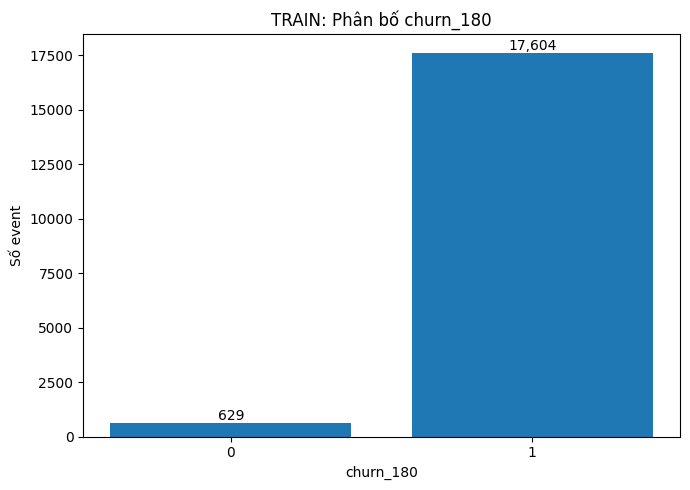

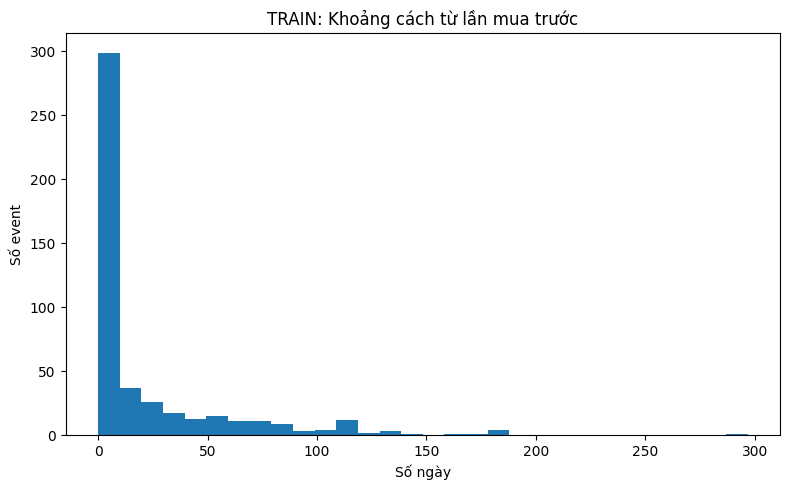

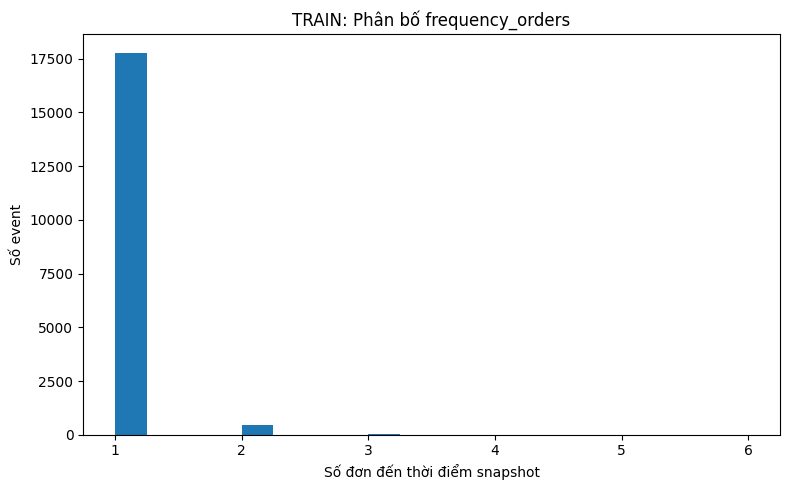

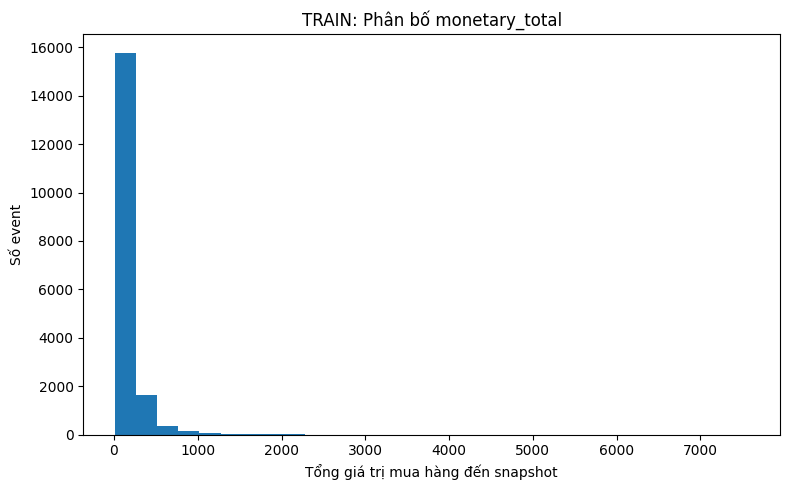


✓ Hoàn tất trực quan hóa TRAIN bằng Matplotlib
✓ Không sử dụng TEST để tạo hoặc điều chỉnh feature


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import functions as F

plot_source = (
    raw
    .filter(F.col("temporal_split") == "train")
    .select(
        F.col("churn_180").cast("int").alias("churn_180"),
        F.expr(
            "try_cast(days_since_previous_purchase as double)"
        ).alias("days_since_previous_purchase"),
        F.expr(
            "try_cast(frequency_orders as double)"
        ).alias("frequency_orders"),
        F.expr(
            "try_cast(monetary_total as double)"
        ).alias("monetary_total")
    )
    .toPandas()
)

numeric_columns = [
    "churn_180",
    "days_since_previous_purchase",
    "frequency_orders",
    "monetary_total"
]

for col in numeric_columns:
    plot_source[col] = pd.to_numeric(
        plot_source[col],
        errors="coerce"
    )

plot_source = plot_source.replace(
    [np.inf, -np.inf],
    np.nan
)

print("=" * 70)
print("TRAIN DATA USED FOR FEATURE VISUALIZATION")
print("=" * 70)

print("Số event TRAIN:", len(plot_source))

print(
    "\nPhân bố churn_180:"
)

print(
    plot_source["churn_180"]
    .value_counts(dropna=False)
    .sort_index()
)

print(
    "\nMissing:"
)

print(
    plot_source[
        [
            "days_since_previous_purchase",
            "frequency_orders",
            "monetary_total"
        ]
    ]
    .isna()
    .sum()
)

churn_pd = (
    plot_source["churn_180"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    churn_pd.index.astype(str),
    churn_pd.values
)

plt.title(
    "TRAIN: Phân bố churn_180"
)

plt.xlabel(
    "churn_180"
)

plt.ylabel(
    "Số event"
)

for bar, value in zip(
    bars,
    churn_pd.values
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

gap_data = (
    plot_source[
        "days_since_previous_purchase"
    ]
    .dropna()
)

if len(gap_data) > 0:
    plt.figure(figsize=(8, 5))

    plt.hist(
        gap_data,
        bins=30
    )

    plt.title(
        "TRAIN: Khoảng cách từ lần mua trước"
    )

    plt.xlabel(
        "Số ngày"
    )

    plt.ylabel(
        "Số event"
    )

    plt.tight_layout()
    plt.show()
else:
    print(
        "\nKhông có dữ liệu hợp lệ cho "
        "days_since_previous_purchase."
    )

frequency_data = (
    plot_source[
        "frequency_orders"
    ]
    .dropna()
)

if len(frequency_data) > 0:
    plt.figure(figsize=(8, 5))

    plt.hist(
        frequency_data,
        bins=20
    )

    plt.title(
        "TRAIN: Phân bố frequency_orders"
    )

    plt.xlabel(
        "Số đơn đến thời điểm snapshot"
    )

    plt.ylabel(
        "Số event"
    )

    plt.tight_layout()
    plt.show()
else:
    print(
        "\nKhông có dữ liệu hợp lệ cho "
        "frequency_orders."
    )

monetary_data = (
    plot_source[
        "monetary_total"
    ]
    .dropna()
)

if len(monetary_data) > 0:
    plt.figure(figsize=(8, 5))

    plt.hist(
        monetary_data,
        bins=30
    )

    plt.title(
        "TRAIN: Phân bố monetary_total"
    )

    plt.xlabel(
        "Tổng giá trị mua hàng đến snapshot"
    )

    plt.ylabel(
        "Số event"
    )

    plt.tight_layout()
    plt.show()
else:
    print(
        "\nKhông có dữ liệu hợp lệ cho "
        "monetary_total."
    )

print(
    "\n✓ Hoàn tất trực quan hóa TRAIN bằng Matplotlib"
)

print(
    "✓ Không sử dụng TEST để tạo hoặc điều chỉnh feature"
)

## Cell 09 — Lưu baseline 24 feature và bộ candidate mở rộng

Để không phá vỡ pipeline SMOTENC/Machine Learning hiện tại, `olist_customer_churn_features_selected` vẫn giữ baseline 24 feature đã dùng trước đó. Các feature bổ sung được lưu riêng để đánh giá trước khi đưa vào model chính thức.


In [18]:
import json
from pathlib import Path

raw = read_csv(
    feature_output_dir
)

if (
    "FINAL_FEATURES"
    not in globals()
):
    raise RuntimeError(
        "Chưa có FINAL_FEATURES. "
        "Hãy chạy Cell 06 và Cell 07 trước."
    )

if not FINAL_FEATURES:
    raise ValueError(
        "FINAL_FEATURES đang rỗng."
    )

OUTPUT_ID_COLUMNS = [
    "customer_unique_id",
    "snapshot_order_id",
    "snapshot_at",
    "snapshot_date",
    "followup_end_180",
    "temporal_split",
    "churn_180"
]

required_columns = (
    OUTPUT_ID_COLUMNS
    + FINAL_FEATURES
)

missing_columns = [
    c
    for c
    in required_columns
    if c not in raw.columns
]

if missing_columns:

    raise ValueError(
        "Dataset temporal đang thiếu các cột:\n"
        + "\n".join(
            missing_columns
        )
    )

final_model_data = (
    raw
    .select(
        *OUTPUT_ID_COLUMNS,
        *FINAL_FEATURES
    )
)

total_rows = (
    final_model_data
    .count()
)

duplicate_keys = (
    final_model_data
    .groupBy(
        "customer_unique_id",
        "snapshot_order_id"
    )
    .count()
    .filter(
        F.col("count") > 1
    )
    .count()
)

invalid_target = (
    final_model_data
    .filter(
        F.col(
            "churn_180"
        ).isNull()
        |
        ~F.col(
            "churn_180"
        )
        .cast("int")
        .isin(
            0,
            1
        )
    )
    .count()
)

if duplicate_keys > 0:

    raise ValueError(
        f"Phát hiện {duplicate_keys} "
        "duplicate observation key."
    )

if invalid_target > 0:

    raise ValueError(
        f"Phát hiện {invalid_target} "
        "target churn_180 không hợp lệ."
    )

(
    final_model_data
    .repartition(
        8,
        "snapshot_date"
    )
    .write
    .mode(
        "overwrite"
    )
    .option(
        "header",
        True
    )
    .csv(
        str(
            selected_output_dir
        )
    )
)

quality_report_path = (
    processed_dir
    / "olist_feature_quality_train.csv"
)

correlation_report_path = (
    processed_dir
    / "olist_feature_high_correlation_train.csv"
)

metadata_path = (
    processed_dir
    / "olist_customer_churn_features_selected_metadata.json"
)

quality_df.to_csv(
    quality_report_path,
    index=False
)

correlation_pairs_df.to_csv(
    correlation_report_path,
    index=False
)

selection_metadata = {
    "target":
        TARGET_COLUMN,

    "selection_data":
        "train_only",

    "high_missing_threshold_pct":
        HIGH_MISSING_THRESHOLD,

    "high_correlation_threshold":
        HIGH_CORRELATION_THRESHOLD,

    "candidate_feature_count":
        len(
            CANDIDATE_FEATURES
        ),

    "final_feature_count":
        len(
            FINAL_FEATURES
        ),

    "constant_features_removed":
        constant_features,

    "high_missing_features_removed":
        high_missing_features,

    "high_correlation_features_removed":
        {
            feature: {
                "correlated_with":
                    info[
                        "correlated_with"
                    ],

                "correlation":
                    info[
                        "correlation"
                    ]
            }
            for feature, info
            in correlated_drops.items()
        },

    "final_features":
        FINAL_FEATURES
}

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        selection_metadata,
        f,
        ensure_ascii=False,
        indent=2
    )

split_summary = (
    final_model_data
    .groupBy(
        "temporal_split"
    )
    .agg(
        F.count(
            "*"
        ).alias(
            "so_event"
        ),

        F.countDistinct(
            "customer_unique_id"
        ).alias(
            "so_khach"
        ),

        F.sum(
            F.when(
                F.col(
                    "churn_180"
                ) == 1,
                1
            ).otherwise(
                0
            )
        ).alias(
            "so_churn"
        ),

        F.sum(
            F.when(
                F.col(
                    "churn_180"
                ) == 0,
                1
            ).otherwise(
                0
            )
        ).alias(
            "so_non_churn"
        ),

        F.round(
            100
            * F.avg(
                F.col(
                    "churn_180"
                ).cast(
                    "double"
                )
            ),
            2
        ).alias(
            "ty_le_churn_pct"
        )
    )
    .orderBy(
        "temporal_split"
    )
)

print("=" * 70)
print("FINAL FEATURE DATASET")
print("=" * 70)

print(
    "Output:",
    selected_output_dir
)

print(
    "Tổng số event:",
    total_rows
)

print(
    "Duplicate observation key:",
    duplicate_keys
)

print(
    "Invalid target:",
    invalid_target
)

print(
    "Candidate features ban đầu:",
    len(
        CANDIDATE_FEATURES
    )
)

print(
    "Final features:",
    len(
        FINAL_FEATURES
    )
)

print(
    "\nFeature quality report:",
    quality_report_path
)

print(
    "Correlation report:",
    correlation_report_path
)

print(
    "Metadata:",
    metadata_path
)

print(
    "\nPHÂN BỐ TEMPORAL SPLIT"
)

split_summary.show(
    truncate=False
)

print(
    "\nFINAL_FEATURES"
)

for i, feature in enumerate(
    FINAL_FEATURES,
    start=1
):

    print(
        f"{i:02d}. {feature}"
    )

print(
    "\n✓ Dataset feature cuối cùng "
    "được tạo hoàn toàn từ pipeline mới."
)

print(
    "✓ Không còn baseline 24 feature."
)

print(
    "✓ Không còn supplementary feature "
    "từ notebook cũ."
)

print(
    "✓ Bước 06 SMOTENC phải đọc "
    "olist_customer_churn_features_selected."
)

FINAL FEATURE DATASET
Output: /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_customer_churn_features_selected
Tổng số event: 58372
Duplicate observation key: 0
Invalid target: 0
Candidate features ban đầu: 48
Final features: 27

Feature quality report: /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_feature_quality_train.csv
Correlation report: /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_feature_high_correlation_train.csv
Metadata: /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_customer_churn_features_selected_metadata.json

PHÂN BỐ TEMPORAL SPLIT
+--------------+--------+--------+--------+------------+---------------+
|temporal_split|so_event|so_khach|so_churn|so_non_churn|ty_le_churn_pct|
+--------------+--------+--------+--------+------------+---------------+
|embargo       |32531   |31755   |31491   |1040        |96.8           |
|test          |7608    |7400    |6672    |936         |87.7        

## Cell 10 — Giải phóng cache và hoàn tất


In [14]:
history.unpersist()
order_facts.unpersist()
snapshots.unpersist()
features.unpersist()

print("Hoàn tất Feature Engineering.")


Hoàn tất Feature Engineering.


## Kết quả của notebook

- `processed/olist_customer_churn_features_temporal`: toàn bộ feature snapshot-aware + temporal split.
- `processed/olist_customer_churn_features_selected`: baseline 24 feature.
- `processed/olist_customer_churn_features_candidates_extended`: baseline 24 + 10 featurefeature.
